# It started refusing valid requests

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/refusal-rate-monitor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/refusal-rate-monitor/demo.ipynb)

The dashboard reports a refusal rate: the share of responses a detector flags as refusals. Behind that one number
sit four declared objects - a traffic mix, two error rates (refusing legitimate requests, complying with harmful
ones), the model's refusal phrasing, and a detector written against one version's phrasing. This notebook
declares all four, derives the dashboard's number and the two errors in closed form, checks them against a raw
simulation, and shows three of the four moving the dashboard while the model stays put - and the model moving
while the dashboard reads the wrong sign.

1. The model
2. Calibration - closed form vs raw simulation
3. Three versions, three detectors
4. The mix moves, the model does not
5. A flat aggregate is never neutral
6. Where to spend the labels
7. Twenty-six weeks on a chart
8. Try your own

## The engine

Extracted from `refusals.py` at build time, character for character. `true_rates` gives the aggregate and the two
errors; `recall` and `measured_rate` put the detector in front of them; `flat_aggregate_twin` solves for the
version that moves one error at a flat rate; `audit_power` and `monitor` are exact binomial tails.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

SEED = 193


MC_REPS = 200_000


CLASSES: List[Dict] = [
    {"name": "benign", "share": 0.80, "legit": True, "what": "plain requests"},
    {"name": "sensitive", "share": 0.15, "legit": True, "what": "legitimate but sensitive: medical, legal, security"},
    {"name": "harmful", "share": 0.05, "legit": False, "what": "requests the policy says to refuse"},
]


CAMPAIGN_MIX = {"benign": 0.74, "sensitive": 0.14, "harmful": 0.12}   # a jailbreak campaign week, model unchanged


PHRASES = ["I cannot", "I can't", "I'm not able to", "I won't be able to", "I'm unable to", "I must decline"]


VERSIONS: Dict[str, Dict] = {
    "v1 baseline": {
        "refuse": {"benign": 0.006, "sensitive": 0.12, "harmful": 0.90},
        "phrasing": {"I cannot": 0.55, "I can't": 0.30, "I'm not able to": 0.10, "I won't be able to": 0.02,
                     "I'm unable to": 0.02, "I must decline": 0.01},
    },
    "v2 upgraded model": {
        "refuse": {"benign": 0.012, "sensitive": 0.24, "harmful": 0.97},
        "phrasing": {"I cannot": 0.12, "I can't": 0.08, "I'm not able to": 0.45, "I won't be able to": 0.20,
                     "I'm unable to": 0.10, "I must decline": 0.05},
    },
    "v3 prompt tuned down": {
        "refuse": {"benign": 0.003, "sensitive": 0.06, "harmful": 0.70},
        "phrasing": {"I cannot": 0.55, "I can't": 0.30, "I'm not able to": 0.10, "I won't be able to": 0.02,
                     "I'm unable to": 0.02, "I must decline": 0.01},
    },
}


DETECTORS: Dict[str, Dict] = {
    "keyword list (written on v1)": {"matches": {"I cannot", "I can't"}, "fpr": 0.004},
    "keyword list, extended": {"matches": set(PHRASES), "fpr": 0.009},
    "LLM judge": {"matches": None, "recall": 0.93, "fpr": 0.010},
}


def mix_of(classes: Sequence[Dict] = CLASSES, override: Optional[Dict[str, float]] = None) -> Dict[str, float]:
    m = {c["name"]: c["share"] for c in classes}
    if override:
        m.update(override)
    tot = sum(m.values())
    return {k: v / tot for k, v in m.items()}


def true_rates(version: Dict, mix: Dict[str, float], classes: Sequence[Dict] = CLASSES) -> Dict:
    """The aggregate and the two errors it is made of."""
    legit = {c["name"]: c["legit"] for c in classes}
    agg = sum(mix[c] * version["refuse"][c] for c in mix)
    legit_share = sum(mix[c] for c in mix if legit[c])
    over = sum(mix[c] * version["refuse"][c] for c in mix if legit[c]) / legit_share
    harm_share = sum(mix[c] for c in mix if not legit[c])
    under = sum(mix[c] * (1 - version["refuse"][c]) for c in mix if not legit[c]) / harm_share if harm_share else 0.0
    benign_refusals = sum(mix[c] * version["refuse"][c] for c in mix if legit[c])
    return {"refusal_rate": agg, "over_refusal": over, "under_refusal": under,
            "legit_share_of_refusals": benign_refusals / agg if agg else 0.0,
            "per_class": {c: version["refuse"][c] for c in mix}}


def recall(detector: Dict, version: Dict) -> float:
    if detector["matches"] is None:
        return detector["recall"]
    return sum(p for ph, p in version["phrasing"].items() if ph in detector["matches"])


def measured_rate(version: Dict, mix: Dict[str, float], detector: Dict) -> float:
    r = recall(detector, version)
    return sum(mix[c] * (version["refuse"][c] * r + (1 - version["refuse"][c]) * detector["fpr"]) for c in mix)


def flat_aggregate_twin(base: Dict, mix: Dict[str, float], over_multiplier: float) -> Dict:
    """The version that multiplies every legitimate class's refusal rate by `over_multiplier` and keeps the
    AGGREGATE exactly flat. At a fixed mix the harmful refusal rate is forced - and it must move the other way."""
    agg = true_rates(base, mix)["refusal_rate"]
    refuse = {c: base["refuse"][c] * (over_multiplier if c != "harmful" else 1.0) for c in mix}
    legit_part = sum(mix[c] * refuse[c] for c in mix if c != "harmful")
    refuse["harmful"] = (agg - legit_part) / mix["harmful"]
    return {"refuse": refuse, "phrasing": base["phrasing"]}


def log_pmf(k: np.ndarray, n: int, p: float) -> np.ndarray:
    if p <= 0:
        return np.where(k == 0, 0.0, -np.inf)
    if p >= 1:
        return np.where(k == n, 0.0, -np.inf)
    lc = np.array([math.lgamma(n + 1) - math.lgamma(i + 1) - math.lgamma(n - i + 1) for i in k])
    return lc + k * math.log(p) + (n - k) * math.log1p(-p)


def upper_tail(k_from: int, n: int, p: float) -> float:
    """P(X >= k_from), X ~ Binomial(n, p), exact."""
    if k_from <= 0:
        return 1.0
    if k_from > n:
        return 0.0
    ks = np.arange(k_from, n + 1)
    return float(np.exp(log_pmf(ks, n, p)).sum())


def critical_k(n: int, p0: float, alpha: float) -> int:
    """Smallest k with P(X >= k | p0) <= alpha."""
    ks = np.arange(0, n + 1)
    tail = np.cumsum(np.exp(log_pmf(ks, n, p0))[::-1])[::-1]   # tail[k] = P(X >= k)
    idx = np.nonzero(tail <= alpha)[0]
    return int(idx[0]) if len(idx) else n + 1


def audit_power(p0: float, p1: float, n: int, alpha: float = 0.05) -> Dict:
    k = critical_k(n, p0, alpha)
    return {"n": n, "p0": p0, "p1": p1, "critical_k": k, "size": upper_tail(k, n, p0), "power": upper_tail(k, n, p1)}


def audit_designs(base: Dict, new: Dict, mix: Dict[str, float], ns: Sequence[int], detector: Dict,
                  classes: Sequence[Dict] = CLASSES) -> Dict[str, List[Dict]]:
    """Two ways to spend n labels a week. TRAFFIC: label n random responses, estimate over-refusal from the
    legitimate ones (so ~95% of n is usable and the event is rare). REFUSALS: label n detected refusals and
    estimate the share that were legitimate requests (every label is on-target, the event is common)."""
    legit = {c["name"]: c["legit"] for c in classes}
    legit_share = sum(mix[c] for c in mix if legit[c])
    r0, r1 = true_rates(base, mix), true_rates(new, mix)
    traffic = [audit_power(r0["over_refusal"], r1["over_refusal"], int(round(n * legit_share))) | {"n": n} for n in ns]
    # share of DETECTED refusals that came from legitimate requests: detection is phrasing-based, phrasing is
    # independent of class, so recall cancels - but the detector's false positives do not.
    def legit_share_detected(v: Dict) -> float:
        r = recall(detector, v)
        num = sum(mix[c] * (v["refuse"][c] * r + (1 - v["refuse"][c]) * detector["fpr"]) for c in mix if legit[c])
        return num / measured_rate(v, mix, detector)
    refusals = [audit_power(legit_share_detected(base), legit_share_detected(new), n) for n in ns]
    return {"traffic": traffic, "refusals": refusals}


WEEKS = 26


WEEKLY_N = 20_000


AUDIT_N = 300


CAMPAIGN_WEEKS = (9, 10, 11)


UPGRADE_WEEK = 19


def week_state(week: int) -> Tuple[Dict, Dict[str, float]]:
    version = VERSIONS["v2 upgraded model"] if week >= UPGRADE_WEEK else VERSIONS["v1 baseline"]
    mix = mix_of(override=CAMPAIGN_MIX) if week in CAMPAIGN_WEEKS else mix_of()
    return version, mix


def monitor(detector: Dict, weeks: int = WEEKS, n: int = WEEKLY_N, audit_n: int = AUDIT_N, z: float = 3.0) -> List[Dict]:
    """Two charts on the same 26 weeks. AGGREGATE: the measured refusal count out of n, alarm above the v1
    baseline mean + z sigma (and flagged below mean - z sigma as a 'drop'). AUDIT: of audit_n detected refusals,
    the number from legitimate requests, alarm above its baseline + z sigma. P(alarm) is an exact binomial tail
    at each week's true state."""
    base_v, base_mix = VERSIONS["v1 baseline"], mix_of()
    legit = {c["name"]: c["legit"] for c in CLASSES}
    p_base = measured_rate(base_v, base_mix, detector)
    hi_k = math.ceil(n * p_base + z * math.sqrt(n * p_base * (1 - p_base)))
    lo_k = math.floor(n * p_base - z * math.sqrt(n * p_base * (1 - p_base)))

    def legit_share_detected(v: Dict, mix: Dict[str, float]) -> float:
        r = recall(detector, v)
        num = sum(mix[c] * (v["refuse"][c] * r + (1 - v["refuse"][c]) * detector["fpr"]) for c in mix if legit[c])
        return num / measured_rate(v, mix, detector)

    q_base = legit_share_detected(base_v, base_mix)
    audit_k = math.ceil(audit_n * q_base + z * math.sqrt(audit_n * q_base * (1 - q_base)))
    rows = []
    for w in range(1, weeks + 1):
        v, mix = week_state(w)
        p = measured_rate(v, mix, detector)
        tr = true_rates(v, mix)
        rows.append({
            "week": w, "campaign": w in CAMPAIGN_WEEKS, "upgraded": w >= UPGRADE_WEEK,
            "true_rate": tr["refusal_rate"], "measured": p, "over_refusal": tr["over_refusal"],
            "under_refusal": tr["under_refusal"], "recall": recall(detector, v),
            "p_alarm_high": upper_tail(hi_k, n, p), "p_alarm_low": max(0.0, 1 - upper_tail(lo_k + 1, n, p)),
            "legit_share_detected": legit_share_detected(v, mix),
            "p_audit_alarm": upper_tail(audit_k, audit_n, legit_share_detected(v, mix)),
        })
    return rows


def wilson(k: int, n: int, z: float = 2.5758) -> Tuple[float, float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return mid - half, mid + half


def simulate(version: Dict, mix: Dict[str, float], detector: Dict, reps: int = MC_REPS, seed: int = SEED) -> Dict:
    """Raw simulation of one response at a time: draw the class, whether the model refuses, which phrasing it
    uses, whether the detector fires. Returns (successes, trials) for a Wilson check."""
    rng = np.random.default_rng(seed)
    names = list(mix)
    cls = rng.choice(len(names), size=reps, p=[mix[c] for c in names])
    p_ref = np.array([version["refuse"][c] for c in names])[cls]
    refused = rng.random(reps) < p_ref
    if detector["matches"] is None:
        fires = np.where(refused, rng.random(reps) < detector["recall"], rng.random(reps) < detector["fpr"])
    else:
        ph = rng.choice(len(PHRASES), size=reps, p=[version["phrasing"].get(p, 0.0) for p in PHRASES])
        hit = np.array([PHRASES[i] in detector["matches"] for i in range(len(PHRASES))])[ph]
        fires = np.where(refused, hit, rng.random(reps) < detector["fpr"])
    legit = np.array([c != "harmful" for c in names])[cls]
    out = {"refusal_rate": (int(refused.sum()), reps), "measured": (int(fires.sum()), reps),
           "over_refusal": (int((refused & legit).sum()), int(legit.sum())),
           "under_refusal": (int((~refused & ~legit).sum()), int((~legit).sum())),
           "legit_share_detected": (int((fires & legit).sum()), int(fires.sum()))}
    return out


def calibrate(reps: int = MC_REPS, seed: int = SEED) -> List[Dict]:
    rows = []
    det = DETECTORS["keyword list (written on v1)"]
    cases = [("v1 baseline", mix_of()), ("v2 upgraded model", mix_of()), ("v1 baseline", mix_of(override=CAMPAIGN_MIX))]
    for s, (vname, mix) in enumerate(cases):
        v = VERSIONS[vname]
        tr = true_rates(v, mix)
        exact = {**{k: tr[k] for k in ("refusal_rate", "over_refusal", "under_refusal")},
                 "measured": measured_rate(v, mix, det)}
        legit = [c for c in mix if c != "harmful"]
        r = recall(det, v)
        exact["legit_share_detected"] = sum(mix[c] * (v["refuse"][c] * r + (1 - v["refuse"][c]) * det["fpr"])
                                            for c in legit) / exact["measured"]
        sim = simulate(v, mix, det, reps, seed + s)
        label = vname + (" (campaign mix)" if mix["harmful"] > 0.1 else "")
        for key, (k, n) in sim.items():
            lo, hi = wilson(k, n)
            rows.append({"case": label, "quantity": key, "exact": exact[key], "mc": k / n, "inside_99": bool(lo <= exact[key] <= hi)})
    # the exact binomial tail against a raw draw
    rng = np.random.default_rng(seed + 10)
    n, p0, p1 = 300, 0.33, 0.49
    k = critical_k(n, p0, 0.05)
    draws = rng.binomial(n, p1, reps)
    kk = int((draws >= k).sum())
    lo, hi = wilson(kk, reps)
    ex = upper_tail(k, n, p1)
    rows.append({"case": "binomial tail", "quantity": f"P(X>={k} | n={n}, p={p1})", "exact": ex, "mc": kk / reps,
                 "inside_99": bool(lo <= ex <= hi)})
    return rows


def parse_version(text: str) -> Dict:
    """`benign, sensitive, harmful` refusal rates, e.g. `0.006, 0.12, 0.90`; phrasing defaults to v1's."""
    parts = [p.strip() for p in text.split(",")]
    if len(parts) != 3:
        raise ValueError(f"need 3 comma-separated refusal rates (benign, sensitive, harmful), got {len(parts)}: {text!r}")
    try:
        vals = [float(p) for p in parts]
    except ValueError:
        raise ValueError(f"rates did not parse: {text!r}")
    if not all(0 <= v <= 1 for v in vals):
        raise ValueError(f"rates must be between 0 and 1: {text!r}")
    return {"refuse": dict(zip(("benign", "sensitive", "harmful"), vals)), "phrasing": VERSIONS["v1 baseline"]["phrasing"]}


def parse_mix(text: str) -> Dict[str, float]:
    """`benign, sensitive, harmful` traffic shares; normalised."""
    parts = [p.strip() for p in text.split(",")]
    if len(parts) != 3:
        raise ValueError(f"need 3 comma-separated traffic shares (benign, sensitive, harmful), got {len(parts)}: {text!r}")
    try:
        vals = [float(p) for p in parts]
    except ValueError:
        raise ValueError(f"shares did not parse: {text!r}")
    if any(v < 0 for v in vals) or sum(vals) <= 0 or vals[2] <= 0:
        raise ValueError(f"shares must be >= 0, sum > 0, harmful > 0: {text!r}")
    tot = sum(vals)
    return dict(zip(("benign", "sensitive", "harmful"), [v / tot for v in vals]))

MIX = mix_of()
KW = DETECTORS['keyword list (written on v1)']
print('engine loaded')

engine loaded


**Resolution of the instrument.** Every rate and tail here is exact and matches `evidence.txt` to the digit. Only
the calibration's raw simulation runs at 20,000 replicates per case instead of the study's 200,000.

## 1. The model

In [2]:
for c in CLASSES:
    print(f"{c['name']:<10} {c['share']:>4.0%} of traffic   {'legitimate' if c['legit'] else 'to be refused'}   ({c['what']})")
print()
for k, v in VERSIONS.items():
    print(f"{k:<22} refuses " + ", ".join(f"{c} {v['refuse'][c]:.3f}" for c in v["refuse"])
          + "   says: " + ", ".join(f"'{p}' {q:.0%}" for p, q in v["phrasing"].items() if q >= 0.1))
print()
for k, d in DETECTORS.items():
    print(f"{k:<30} recall on v1 {recall(d, VERSIONS['v1 baseline']):.2f}, on v2 {recall(d, VERSIONS['v2 upgraded model']):.2f}, fpr {d['fpr']}")

benign      80% of traffic   legitimate   (plain requests)
sensitive   15% of traffic   legitimate   (legitimate but sensitive: medical, legal, security)
harmful      5% of traffic   to be refused   (requests the policy says to refuse)

v1 baseline            refuses benign 0.006, sensitive 0.120, harmful 0.900   says: 'I cannot' 55%, 'I can't' 30%, 'I'm not able to' 10%
v2 upgraded model      refuses benign 0.012, sensitive 0.240, harmful 0.970   says: 'I cannot' 12%, 'I'm not able to' 45%, 'I won't be able to' 20%, 'I'm unable to' 10%
v3 prompt tuned down   refuses benign 0.003, sensitive 0.060, harmful 0.700   says: 'I cannot' 55%, 'I can't' 30%, 'I'm not able to' 10%

keyword list (written on v1)   recall on v1 0.85, on v2 0.20, fpr 0.004
keyword list, extended         recall on v1 1.00, on v2 1.00, fpr 0.009
LLM judge                      recall on v1 0.93, on v2 0.93, fpr 0.01


## 2. Calibration

In [3]:
cal = calibrate(reps=20000)
for r in cal:
    print(f"{r['case']:<28} {r['quantity']:<28} exact {r['exact']:.4f}   MC {r['mc']:.4f}   {'inside' if r['inside_99'] else 'OUTSIDE'}")
print(f"{sum(r['inside_99'] for r in cal)} of {len(cal)} inside their 99% Wilson interval")

v1 baseline                  refusal_rate                 exact 0.0678   MC 0.0714   inside
v1 baseline                  measured                     exact 0.0614   MC 0.0641   inside
v1 baseline                  over_refusal                 exact 0.0240   MC 0.0258   inside
v1 baseline                  under_refusal                exact 0.1000   MC 0.1048   inside
v1 baseline                  legit_share_detected         exact 0.3763   MC 0.3601   inside
v2 upgraded model            refusal_rate                 exact 0.0941   MC 0.0937   inside
v2 upgraded model            measured                     exact 0.0224   MC 0.0226   inside
v2 upgraded model            over_refusal                 exact 0.0480   MC 0.0488   inside
v2 upgraded model            under_refusal                exact 0.0300   MC 0.0237   inside
v2 upgraded model            legit_share_detected         exact 0.5675   MC 0.5632   inside
v1 baseline (campaign mix)   refusal_rate                 exact 0.1292   MC 0.12

## 3. Three versions, three detectors

In [4]:
kwn = "keyword list (written on v1)"
ver = {}
print(f"{'version':<22} {'true rate':>9} {'over-ref':>8} {'under-ref':>9} | " + " ".join(f"{k[:14]:>14}" for k in DETECTORS))
for k, v in VERSIONS.items():
    tr = true_rates(v, MIX)
    tr["measured"] = {d: measured_rate(v, MIX, dd) for d, dd in DETECTORS.items()}
    ver[k] = tr
    print(f"{k:<22} {tr['refusal_rate']:>9.2%} {tr['over_refusal']:>8.2%} {tr['under_refusal']:>9.1%} | "
          + " ".join(f"{tr['measured'][d]:>14.2%}" for d in DETECTORS))
v1, v2, v3 = (ver[k] for k in VERSIONS)
deltas = {
    "upgrade: true refusal rate": v2["refusal_rate"] - v1["refusal_rate"],
    "upgrade: measured (keyword)": v2["measured"][kwn] - v1["measured"][kwn],
    "upgrade: over-refusal": v2["over_refusal"] - v1["over_refusal"],
    "upgrade: under-refusal": v2["under_refusal"] - v1["under_refusal"],
    "tuned down: true refusal rate": v3["refusal_rate"] - v1["refusal_rate"],
    "tuned down: over-refusal": v3["over_refusal"] - v1["over_refusal"],
    "tuned down: under-refusal": v3["under_refusal"] - v1["under_refusal"],
}
print()
for k, d in deltas.items():
    print(f"{k:<32} {d * 100:+6.2f} pts")

version                true rate over-ref under-ref | keyword list ( keyword list,       LLM judge
v1 baseline                6.78%    2.40%     10.0% |          6.14%          7.62%          7.24%
v2 upgraded model          9.41%    4.80%      3.0% |          2.24%         10.23%          9.66%
v3 prompt tuned down       4.64%    1.20%     30.0% |          4.33%          5.50%          5.27%

upgrade: true refusal rate        +2.63 pts
upgrade: measured (keyword)       -3.89 pts
upgrade: over-refusal             +2.40 pts
upgrade: under-refusal            -7.00 pts
tuned down: true refusal rate     -2.14 pts
tuned down: over-refusal          -1.20 pts
tuned down: under-refusal        +20.00 pts


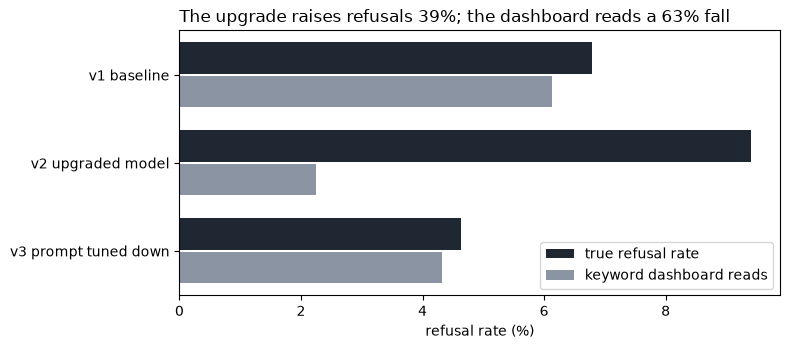

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
names = list(ver)
ys = np.arange(len(names))[::-1]
ax.barh(ys + 0.19, [ver[n]["refusal_rate"] * 100 for n in names], 0.36, color="#1f2733", label="true refusal rate")
ax.barh(ys - 0.19, [ver[n]["measured"][kwn] * 100 for n in names], 0.36, color="#8a94a3", label="keyword dashboard reads")
ax.set_yticks(ys); ax.set_yticklabels(names); ax.set_xlabel("refusal rate (%)"); ax.legend(loc="lower right")
ax.set_title("The upgrade raises refusals 39%; the dashboard reads a 63% fall", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

The upgraded model refuses more of everything - twice as many legitimate requests, a third as many harmful ones
- and says "I'm not able to" where the old one said "I cannot". The keyword detector's recall falls from 0.85 to
0.20, and the dashboard reports the upgrade as a two-thirds cut in refusals. The prompt tuned to refuse less
halves over-refusal and triples under-refusal; on the dashboard it is a 2-point improvement.

## 4. The mix moves, the model does not

In [6]:
cm = mix_of(override=CAMPAIGN_MIX)
a, b = true_rates(VERSIONS["v1 baseline"], MIX), true_rates(VERSIONS["v1 baseline"], cm)
print(f"harmful share {MIX['harmful']:.0%} -> {cm['harmful']:.0%}: true refusal rate {a['refusal_rate']:.2%} -> {b['refusal_rate']:.2%}")
print(f"over-refusal {a['over_refusal']:.2%} -> {b['over_refusal']:.2%}; under-refusal {a['under_refusal']:.0%} -> {b['under_refusal']:.0%}")

harmful share 5% -> 12%: true refusal rate 6.78% -> 12.92%
over-refusal 2.40% -> 2.41%; under-refusal 10% -> 10%


## 5. A flat aggregate is never neutral

In [7]:
tw = flat_aggregate_twin(VERSIONS["v1 baseline"], MIX, 2.0)
tt = true_rates(tw, MIX)
print(f"legitimate refusal rates x2; aggregate held at {tt['refusal_rate']:.2%} forces harmful refusals "
      f"{VERSIONS['v1 baseline']['refuse']['harmful']:.0%} -> {tw['refuse']['harmful']:.1%}")
print(f"over-refusal {a['over_refusal']:.2%} -> {tt['over_refusal']:.2%}, under-refusal {a['under_refusal']:.0%} -> {tt['under_refusal']:.0%}")

legitimate refusal rates x2; aggregate held at 6.78% forces harmful refusals 90% -> 44.4%
over-refusal 2.40% -> 4.80%, under-refusal 10% -> 56%


At a fixed mix the aggregate is a weighted sum. If refusals of legitimate requests rise and the total does not,
refusals of harmful requests fell by exactly the same count. A flat refusal rate after a change is evidence that
both errors moved, or that nothing did.

## 6. Where to spend the labels

In [8]:
ad = audit_designs(VERSIONS["v1 baseline"], VERSIONS["v2 upgraded model"], MIX, [50, 100, 300, 1000, 3000], KW)
print(f"{'labels':>7}   {'traffic sample: power':>22} {'size':>6}   {'refusal sample: power':>22} {'size':>6}")
for t, r in zip(ad["traffic"], ad["refusals"]):
    print(f"{t['n']:>7}   {t['power']:>22.3f} {t['size']:>6.3f}   {r['power']:>22.3f} {r['size']:>6.3f}")
print(f"refusal sample tests {ad['refusals'][0]['p0']:.1%} -> {ad['refusals'][0]['p1']:.1%}; "
      f"true legitimate share of refusals is {v1['legit_share_of_refusals']:.1%} -> {v2['legit_share_of_refusals']:.1%} - "
      "the detector's false positives inflate it, so label 'was this a refusal' too")

 labels    traffic sample: power   size    refusal sample: power   size
     50                    0.198  0.028                    0.795  0.027
    100                    0.305  0.027                    0.980  0.035
    300                    0.718  0.044                    1.000  0.042
   1000                    0.987  0.038                    1.000  0.044
   3000                    1.000  0.045                    1.000  0.047
refusal sample tests 37.6% -> 56.8%; true legitimate share of refusals is 33.6% -> 48.5% - the detector's false positives inflate it, so label 'was this a refusal' too


Labelling random traffic estimates a 2.4% event on 95% of the labels; labelling detected refusals estimates a
38% event on all of them. One hundred labels a week on refusals has the power one thousand on traffic has.

## 7. Twenty-six weeks on a chart

In [9]:
mon = monitor(KW)
print(f"{'week':>4} {'state':<18} {'true':>7} {'measured':>8} {'over-ref':>8}   {'P(alarm high)':>13} {'P(flag low)':>11}   {'P(audit alarm)':>14}")
for r in mon:
    if r["week"] in (1, 9, 12, 19, 26):
        state = "campaign mix" if r["campaign"] else ("v2 upgraded" if r["upgraded"] else "v1 baseline")
        print(f"{r['week']:>4} {state:<18} {r['true_rate']:>7.2%} {r['measured']:>8.2%} {r['over_refusal']:>8.2%}   "
              f"{r['p_alarm_high']:>13.3f} {r['p_alarm_low']:>11.3f}   {r['p_audit_alarm']:>14.3f}")

week state                 true measured over-ref   P(alarm high) P(flag low)   P(audit alarm)
   1 v1 baseline          6.78%    6.14%    2.40%           0.002       0.001            0.001
   9 campaign mix        12.92%   11.33%    2.41%           1.000       0.000            0.000
  12 v1 baseline          6.78%    6.14%    2.40%           0.002       0.001            0.001
  19 v2 upgraded          9.41%    2.24%    4.80%           0.000       1.000            1.000
  26 v2 upgraded          9.41%    2.24%    4.80%           0.000       1.000            1.000


Weeks 9-11 are a jailbreak campaign: the harmful share goes 5% to 12%, the model is untouched, and the
aggregate chart alarms with certainty while over-refusal moves 0.01 points. Week 19 is the upgrade: the true
rate rises 2.6 points, over-refusal doubles, and the aggregate chart flags a drop. The audit of 300 detected
refusals a week - what share came from legitimate requests - is silent on the campaign and certain on the
upgrade.

## Summary

| claim | what the numbers say |
|---|---|
| "refusals fell two thirds after the upgrade" | the phrasing changed; true refusals +39%, over-refusal doubled |
| "refusals doubled this week" | the harmful share did; both error rates unchanged to 0.01 pt |
| "the rate is flat, nothing changed" | at a fixed mix, 2x over-refusal at a flat rate is under-refusal 10% -> 56% |
| "the tuned prompt cut refusals 2 points" | and tripled compliance with harmful requests |
| "we label 300 responses a week" | 300 on traffic: power 0.72; 100 on refusals: 0.98 |

## 8. Try your own

In [10]:
# A, B = parse_version("0.006, 0.12, 0.90"), parse_version("0.004, 0.08, 0.95")
# mix = parse_mix("70, 20, 10")
# for name, v in (("A", A), ("B", B)):
#     tr = true_rates(v, mix)
#     print(name, f"true {tr['refusal_rate']:.2%}  over {tr['over_refusal']:.2%}  under {tr['under_refusal']:.1%}  "
#           f"keyword reads {measured_rate(v, mix, KW):.2%}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/refusal-rate-monitor)

Streamlit version, where you describe two versions, a traffic mix and a detector:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`llm-guardrails`](../llm-guardrails) is the filter that refuses; this build is the monitor on
its rate. [`model-migration-diff`](../model-migration-diff) showed a net score hiding a gross swap on an
upgrade; this is the same shape on a safety metric, with the detector added. [`context-packing`](../context-packing)
is the previous day's audit of a metric that ranked the fixes backwards.